# `predict_cell_type` tutorial — Basal Ganglia Subclass

End-to-end tutorial for cytozip's methylation cell-type classifier
([`predict_cell_type`](../cytozip/model.py) / [`CellTypeClassifier`](../cytozip/model.py)) on real
**Basal Ganglia (BG)** *Subclass* pseudobulks.

## What the classifier does

Given a **shallow / low-coverage** single cell (few reads per cytosine), assign it to one of a
panel of **deep** cell-type pseudobulk references, using a transparent, training-free
naive-Bayes / methylation-frequency deconvolution:

1. For each candidate type `t` and cytosine `c`, estimate a continuous methylation frequency from
   the pseudobulk with Beta shrinkage $\theta_{c,t} = (m_{c,t}+\alpha_0)/(n_{c,t}+\alpha_0+\beta_0)$.
2. Score a query cell as the aggregated per-cytosine Bernoulli log-likelihood, in two independent
   channels (CpG and CpH).
3. Softmax over types &rarr; calibrated probabilities (supports abstention).

## Pipeline

| stage | what | status |
|-------|------|--------|
| 1. Train | fit per-type CpG/CpH frequencies from the Subclass pseudobulks &rarr; save a reusable model store | **this notebook (run now)** |
| 2. Predict | load the trained model, classify query cells | placeholder — run later |
| 3. Validation | held-out accuracy / macro-F1 / confusion matrix | placeholder — run later |
| 4. Benchmark | speed / memory / downsampling sweeps | placeholder — run later |

> The model is saved so that the later `predict_cell_type(..., outdir=OUTDIR)` call **auto-detects it
> and skips fitting** — no need to re-read the pseudobulks.

## 1. Setup &amp; imports

In [1]:
import os, glob, json, time
import numpy as np
import pandas as pd
import cytozip as czip
from cytozip import CellTypeClassifier, predict_cell_type

print('cytozip', getattr(czip, '__version__', '(dev)'))

cytozip 0.3.10.dev15


## 2. Configuration (inputs, outputs, hyper-parameters)

- **`PSEUDOBULK_DIR`** — the `-s` *source*: a directory of per-cell-type deep pseudobulk `.cz`
  (each file's stem is the cell-type name).
- **`REFERENCE`** — the `-e` *reference*: the `build_ref` allc `.cz` supplying the per-row
  `context` (CpG vs CpH split). All pseudobulks are row-aligned to this axis.
- **`OUTDIR`** — where everything (model now, predictions later) is written. The model store goes
  to `OUTDIR/model` (real disk, so a large memmap never spills into a small/RAM `/tmp` &rarr; SIGBUS).

In [2]:
# --- annotation level to train / predict at -----------------------------
LEVEL = 'Subclass'   # classification level: 'Subclass' or 'Class'

# --- inputs -------------------------------------------------------------
PSEUDOBULK_DIR = os.path.expanduser(f'~/Projects/BG/pseudobulk/{LEVEL}/cz')       # -s source (per-type .cz)
REFERENCE      = os.path.expanduser('~/Ref/hg38/hg38_with_chrL.allc.cz')         # -e reference (context axis)

# --- outputs ------------------------------------------------------------
OUTDIR    = os.path.expanduser(f'~/Projects/BG/pseudobulk/{LEVEL}/model_{LEVEL}') # Subclass->model_Subclass, Class->model_Class
MODEL_DIR = os.path.join(OUTDIR, 'model')                                        # trained model store (reused by predict)
os.makedirs(OUTDIR, exist_ok=True)

# --- training hyper-parameters -----------------------------------------
LAMBDA_CG = 1.0    # CpG channel log-weight
LAMBDA_CH = 1.0    # CpH channel log-weight (lower it to rebalance if CpH sites dominate)
TOP_CG    = None #0.10   # keep top 10% most discriminative CpG sites (None = keep all)
TOP_CH    = None #0.05   # keep top 5%  most discriminative CpH sites (None = keep all)
N_JOBS    = 72      # parallel .cz readers during fit

for p in (PSEUDOBULK_DIR, REFERENCE):
    assert os.path.exists(p), f'missing input: {p}'
print('level          :', LEVEL)
print('pseudobulk dir :', PSEUDOBULK_DIR)
print('reference      :', REFERENCE)
print('output dir     :', OUTDIR)
print('model store    :', MODEL_DIR)


level          : Subclass
pseudobulk dir : /home/x-wding2/Projects/BG/pseudobulk/Subclass/cz
reference      : /home/x-wding2/Ref/hg38/hg38_with_chrL.allc.cz
output dir     : /home/x-wding2/Projects/BG/pseudobulk/Subclass/model_Subclass
model store    : /home/x-wding2/Projects/BG/pseudobulk/Subclass/model_Subclass/model


## 3. Inspect the pseudobulk inputs

`fit` now accepts the **directory** directly (`pseudobulks=PSEUDOBULK_DIR`) — each `.cz` file's stem
becomes the cell-type label, and non-`.cz` files are ignored. Here we still build the explicit
`{cell_type: path}` mapping just to **preview** the inputs and to align the `cell_counts` below.


In [3]:
cz_files = sorted(glob.glob(os.path.join(PSEUDOBULK_DIR, '*.cz')))
pseudobulks = {os.path.basename(p)[:-3]: p for p in cz_files}   # stem -> path

print(f'{len(pseudobulks)} cell types found:')
for t, p in pseudobulks.items():
    print(f'  {t:<24s} {os.path.getsize(p)/1e6:8.1f} MB')

32 cell types found:
  ACx_MEIS2_GABA              545.5 MB
  Astrocyte                  2411.0 MB
  CN_Cholinergic_GABA        1090.7 MB
  CN_GABA-Glut                787.6 MB
  CN_LAMP5-CXCL14_GABA       1602.1 MB
  CN_LAMP5-LHX6_GABA          950.8 MB
  CN_LHX8_GABA               1550.3 MB
  CN_MEIS2_GABA              1533.7 MB
  CN_ONECUT1_GABA            1064.8 MB
  CN_ST18_GABA               2764.8 MB
  CN_VIP_GABA                1685.8 MB
  Endo                       1199.0 MB
  F_GABA                     2555.0 MB
  F_Glut                     1814.1 MB
  F_M_GATA3_GABA             2737.0 MB
  F_M_Glut                   2466.5 MB
  Glut                       2053.7 MB
  Lymphocyte                  901.9 MB
  M_Dopa                     1243.5 MB
  Microglia                  2181.0 MB
  OPC                        1822.0 MB
  OT_Granular_GABA           1260.1 MB
  Oligodendrocyte            3265.0 MB
  Pericyte                   1200.3 MB
  SMC                         635.7 MB
  SN

## 4. (Optional) abundance prior — `cell_counts`

`cell_counts` records how many cells belong to each Subclass. It does **not** affect the fitted
frequencies; it is stored on the model and only used at **predict** time when `prior_alpha > 0`
(types weighted by $\pi_t \propto \text{cell\_counts}[t]^{\text{prior\_alpha}}$).

The true per-Subclass cell counts come from the atlas annotation table
`~/Projects/BG/clustering/100kb/annotations.tsv` — we take `value_counts()` on its **`Subclass`**
column. Annotation names use spaces while the `.cz` stems use underscores, so we normalise spaces
→ underscores before aligning to our cell types. Prediction still defaults to a **uniform** prior
(`prior_alpha=0`); set `USE_ABUNDANCE_PRIOR = True` to bake the counts into the model.


In [4]:
USE_ABUNDANCE_PRIOR = False   # keep uniform prior by default; set True to bake in the counts

# True per-LEVEL cell counts from the atlas annotation table.
ANNOT_TSV = os.path.expanduser('~/Projects/BG/clustering/100kb/annotations.tsv')

vc = pd.read_csv(ANNOT_TSV, sep='\t', usecols=[LEVEL])[LEVEL].value_counts()
counts_all = {str(name).replace(' ', '_'): int(n) for name, n in vc.items()}   # spaces -> underscores

cell_counts = {t: counts_all[t] for t in pseudobulks if t in counts_all}
missing = [t for t in pseudobulks if t not in counts_all]
print(f'{len(vc)} {LEVEL}s in annotations; matched {len(cell_counts)}/{len(pseudobulks)} pseudobulk types')
if missing:
    print('unmatched pseudobulk types:', missing)
print('example counts:', dict(list(cell_counts.items())[:5]))


31 Subclasss in annotations; matched 25/32 pseudobulk types
unmatched pseudobulk types: ['ACx_MEIS2_GABA', 'Glut', 'OT_Granular_GABA', 'SN_PAX7_GABA', 'STR_D1_MSN', 'STR_D2_MSN', 'STR_Hybrid_MSN']
example counts: {'Astrocyte': 8829, 'CN_Cholinergic_GABA': 360, 'CN_GABA-Glut': 122, 'CN_LAMP5-CXCL14_GABA': 1315, 'CN_LAMP5-LHX6_GABA': 263}


## 5. Train — fit the classifier and save the model store

`fit` reads every pseudobulk `.cz` once, estimates the per-type CpG/CpH frequencies, keeps the
`top_cg` / `top_ch` most discriminative sites, and spills the `(n_sites x n_types)` log-likelihood
tables to memory-mappable `.npy` files. Passing `outdir=MODEL_DIR` routes that store **straight to
real disk**; `save(MODEL_DIR)` then writes the `meta.json` header.

This is the same fitting `predict_cell_type` does internally — pre-computing it here means the later
predict/validation/benchmark calls just **load** this model and skip fitting.

In [5]:
t0 = time.time()
clf = CellTypeClassifier(lambda_cg=LAMBDA_CG, lambda_ch=LAMBDA_CH).fit(
    pseudobulks=PSEUDOBULK_DIR,                            # pass the directory directly (stem = cell type)
    reference=REFERENCE,                                   # supplies per-row context (CpG/CpH split)
    cell_counts=(cell_counts if USE_ABUNDANCE_PRIOR else None),
    top_cg=TOP_CG, top_ch=TOP_CH,                          # keep only discriminative sites
    n_jobs=N_JOBS,
    outdir=MODEL_DIR,                                      # memmap store -> real disk (avoids /tmp SIGBUS)
)
clf.save(MODEL_DIR)                                        # write meta.json (arrays already in MODEL_DIR)
print(f'trained {len(clf.cell_types)} cell types in {time.time() - t0:.1f}s')
print('model saved to', MODEL_DIR)


2026-08-09 19:47:07.772 | INFO     | cytozip.model:fit:851 - found existing model at /home/x-wding2/Projects/BG/pseudobulk/Subclass/model_Subclass/model; skipping fit and loading it


2026-08-09 19:47:08.224 | INFO     | cytozip.model:save:2333 - saved CellTypeClassifier to /home/x-wding2/Projects/BG/pseudobulk/Subclass/model_Subclass/model


trained 32 cell types in 0.5s
model saved to /home/x-wding2/Projects/BG/pseudobulk/Subclass/model_Subclass/model


## 6. Inspect the trained model

Confirm what `fit` selected and the on-disk footprint of the reusable store.

In [6]:
meta = json.load(open(os.path.join(MODEL_DIR, 'meta.json')))
print('cell types      :', len(meta['cell_types']))
print('CpG sites kept  :', meta['cg']['n_sites'] if meta['cg'] else 0)
print('CpH sites kept  :', meta['ch']['n_sites'] if meta['ch'] else 0)
print('alpha0/beta0 CG :', meta['alpha0_cg'], '/', meta['beta0_cg'])
print('alpha0/beta0 CH :', meta['alpha0_ch'], '/', meta['beta0_ch'])

store_size = sum(os.path.getsize(os.path.join(MODEL_DIR, f)) for f in os.listdir(MODEL_DIR))
print('model store size: %.1f MB' % (store_size / 1e6))
print('files           :', sorted(os.listdir(MODEL_DIR)))

cell types      : 32
CpG sites kept  : 58763408
CpH sites kept  : 1141637743
alpha0/beta0 CG : 0.7600007373931021 / 0.16517915238047134
alpha0/beta0 CH : 0.12458260023888149 / 2.6251302249570063
model store size: 312104.3 MB
files           : ['cg_log1m_theta.npy', 'cg_log_theta.npy', 'cg_sites.npy', 'ch_log1m_theta.npy', 'ch_log_theta.npy', 'ch_sites.npy', 'meta.json']


---
## 7. Predict for single-cell cz (deep sequencing using snm3C-seq)

Query set: **deep** snm3C-seq single cells pooled across all
`~/Projects/BICAN/downloaded/*/cz/*.cz` brain regions, intersected with `META_TSV` and randomly
subsampled to `N_QUERY` (=2000). `predict_cell_type` detects the trained model under `OUTDIR/model`
and **skips fitting**, then writes `<prefix>predictions.csv` + `<prefix>predict_proba.csv` to `OUTDIR`.
`query` here is a `{cell_id: path}` dict, but it can also be a directory of single-cell `.cz`, a
concatenated multi-cell `.cz`, or a 2-column `[cell_id, cz_path]` table.

In [7]:
# --- query cells: 2000 random deep single-cell .cz from BICAN -----------
# Pool all downloaded deep-seq .cz across brain regions, keep only cells that
# are annotated in META_TSV (intersection), then randomly pick N_QUERY.
META_TSV = os.path.expanduser('~/Projects/BG/clustering/100kb/cell_metadata_with_annotation.tsv')
N_QUERY  = 2000
SEED     = 0

_id_col   = pd.read_csv(META_TSV, sep='\t', nrows=1).columns[0]
_meta_ids = set(pd.read_csv(META_TSV, sep='\t', usecols=[_id_col])[_id_col].astype(str))

_all_cz = glob.glob(os.path.expanduser('~/Projects/BICAN/downloaded/*/cz/*.cz'))
_pool = {os.path.basename(p)[:-3]: p for p in _all_cz
         if os.path.basename(p)[:-3] in _meta_ids}          # stem -> path, in META only
_ids = sorted(_pool)
rng = np.random.default_rng(SEED)
_pick = rng.choice(len(_ids), size=min(N_QUERY, len(_ids)), replace=False)
query = {_ids[i]: _pool[_ids[i]] for i in _pick}            # {cell_id: cz_path}
print(f'{len(_all_cz)} deep .cz found; {len(_pool)} intersect META_TSV; '
      f'sampled {len(query)} query cells')

# The model under OUTDIR/model is reused (fit is skipped); a dict query
# -> batch predict, returning (labels, proba) and writing them to OUTDIR.
#
# Two independent depth corrections for DEEP snm3C-seq queries (the model is
# calibrated for shallow / MiSeq cells, cov~=1 per site):
#   * cov_cap : cap each site's EFFECTIVE coverage (keeping beta = mc/cov).
#     The reads at one cytosine in a single cell measure the same 1-2
#     molecules, so they are NOT independent Bernoulli draws; without a cap a
#     deep site contributes ~cov x a shallow site's evidence -> softmax
#     saturates at 1.0 and neighbouring types get mis-called. cov_cap=1 makes
#     every covered site count as ONE observation, matching MiSeq. This is the
#     key fix for "deep < MiSeq".
#   * max_query_cg/ch : cap the NUMBER of sites scored per cell (already here).
COV_CAP      = 1        # per-site effective-coverage cap (1 = MiSeq-like); None = raw
MAX_QUERY_CG = 5000
MAX_QUERY_CH = 10000
t0 = time.time()
labels, proba = predict_cell_type(
    query=query,
    outdir=OUTDIR,             # reuses OUTDIR/model
    prefix='m3c_ds5k_',        # separate prefix -> keeps the full-depth m3c_*.csv intact
    reference=REFERENCE,       # only used if the model must be re-fit
    prior_alpha=0.0,           # uniform prior
    cov_cap=COV_CAP,           # per-site depth cap (deep-seq calibration fix)
    max_query_cg=MAX_QUERY_CG, max_query_ch=MAX_QUERY_CH,   # cap sites/cell (None = full depth)
    n_jobs=N_JOBS,
)
print(f'predicted {len(labels)} cells in {time.time() - t0:.1f}s')
print('confidence: mean=%.3f  median=%.3f' % (labels['confidence'].mean(),
                                              labels['confidence'].median()))
labels.head()


2026-08-09 19:47:11.318 | INFO     | cytozip.model:fit:851 - found existing model at /home/x-wding2/Projects/BG/pseudobulk/Subclass/model_Subclass/model; skipping fit and loading it


422321 deep .cz found; 253844 intersect META_TSV; sampled 2000 query cells


2026-08-10 03:19:18.505 | INFO     | cytozip.model:predict_cell_type:2650 - wrote predictions to /home/x-wding2/Projects/BG/pseudobulk/Subclass/model_Subclass


predicted 2000 cells in 27131.0s
confidence: mean=0.997  median=1.000


,label,confidence
cell_id,,
HBA_220303_H1930002_CX47_Pu_3C_1_P6-2-J3-E3,Oligodendrocyte,1.000000
UCI5224_CX1516_CaB_1_P3-1-O5-D14,STR_D1_MSN,1.000000
UWA7648_CX17212224_Pu_2_P12-1-P11-G13,STR_D2_MSN,1.000000
HBA_220518_H1930004_CX46_CaB_3C_1_P5-3-K9-B17,STR_D1_MSN,0.999524
HBA_210121_H1930001_CX45_CaB_1_P1-1-A1-P2,STR_D1_MSN,1.000000


## 8. Validation

**Do not run yet.** Evaluate the classifier on cells with known labels (e.g. held-out single cells or
downsampled pseudobulks): overall accuracy, **macro-F1** (fair to rare types), and the confusion
matrix. To be filled in when the labelled query set is provided.

In [8]:
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve, auc)
from sklearn.preprocessing import label_binarize

META_TSV = os.path.expanduser('~/Projects/BG/clustering/100kb/cell_metadata_with_annotation.tsv')

# read only the cell-id column (first) + LEVEL, keyed by cell id
_id_col = pd.read_csv(META_TSV, sep='\t', nrows=1).columns[0]
meta = pd.read_csv(META_TSV, sep='\t', usecols=[_id_col, LEVEL],
                   dtype=str).set_index(_id_col)
matched = labels.index.isin(meta.index).sum()
print(f"metadata id column: {_id_col!r}; {matched}/{len(labels)} query cells matched")

# true labels aligned to predictions; spaces -> underscores to match model classes
y_true_all = (meta[LEVEL].reindex(labels.index)
              .str.replace(' ', '_', regex=False))
model_classes = list(proba.columns)
mask = y_true_all.notna() & y_true_all.isin(model_classes)
n_out = int((y_true_all.notna() & ~y_true_all.isin(model_classes)).sum())
print(f'{int(mask.sum())}/{len(labels)} cells evaluable '
      f'(labelled & label in the {len(model_classes)} model classes); '
      f'{n_out} labelled but outside model, {int(y_true_all.isna().sum())} unlabelled')

y_true = y_true_all[mask]
y_pred = labels.loc[mask, 'label']
present = [c for c in model_classes if (y_true == c).any()]     # classes actually seen
P = proba.loc[mask, present]
Yb = label_binarize(y_true, classes=present)
Pp = P.values

# ---- headline metrics --------------------------------------------------
acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, labels=present, average='macro', zero_division=0)
f1_micro = f1_score(y_true, y_pred, labels=present, average='micro', zero_division=0)
auc_macro = roc_auc_score(Yb, Pp, average='macro')
auc_micro = roc_auc_score(Yb, Pp, average='micro')
ap_macro = average_precision_score(Yb, Pp, average='macro')
ap_micro = average_precision_score(Yb, Pp, average='micro')

print('\n=== overall ===')
print(f'evaluated cells  : {len(y_true)}   classes seen: {len(present)}/{len(model_classes)}')
print(f'accuracy         : {acc:.4f}')
print(f'F1  macro / micro: {f1_macro:.4f} / {f1_micro:.4f}')
print(f'AUC macro / micro: {auc_macro:.4f} / {auc_micro:.4f}')
print(f'AP  macro / micro: {ap_macro:.4f} / {ap_micro:.4f}  (PRC)')

FIG_DIR = os.path.join(OUTDIR, 'validation')
os.makedirs(FIG_DIR, exist_ok=True)


metadata id column: 'cell'; 2000/2000 query cells matched
1990/2000 cells evaluable (labelled & label in the 32 model classes); 10 labelled but outside model, 0 unlabelled

=== overall ===
evaluated cells  : 1990   classes seen: 32/32
accuracy         : 0.9643
F1  macro / micro: 0.9826 / 0.9643
AUC macro / micro: 0.9991 / 0.9992
AP  macro / micro: 0.9880 / 0.9682  (PRC)


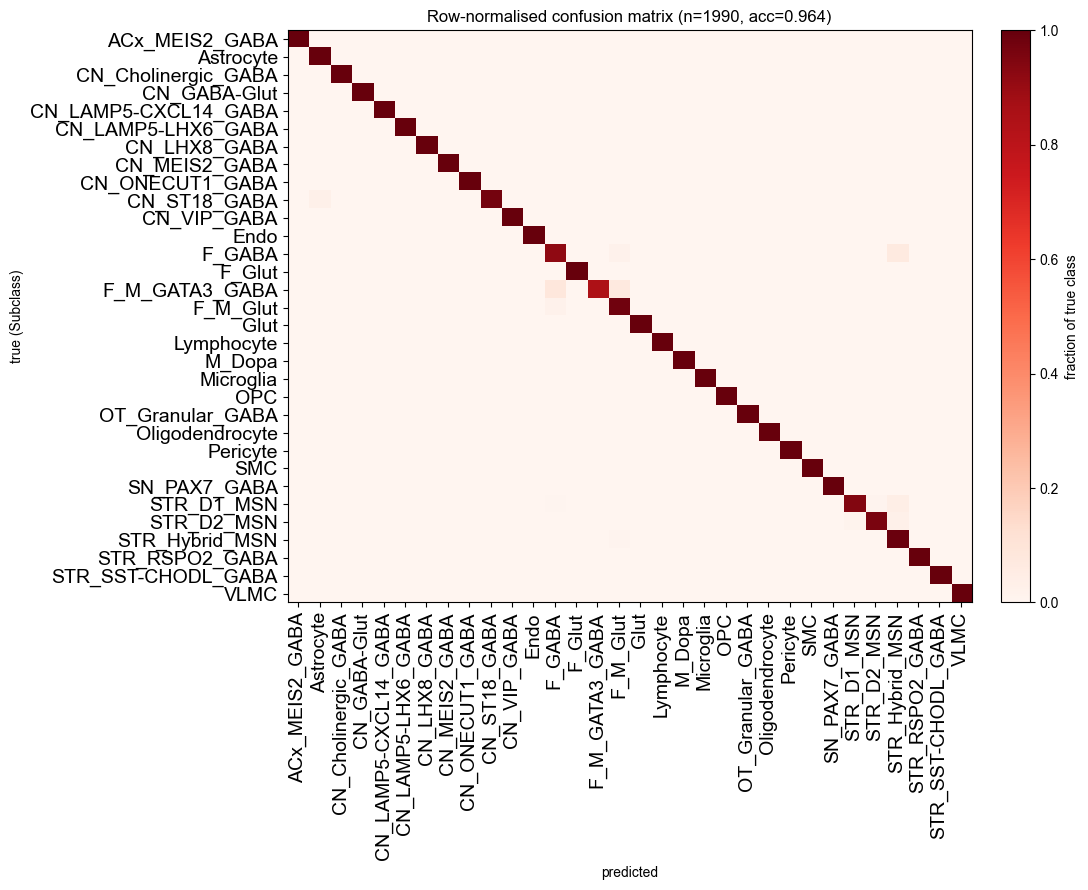

In [9]:
# --- row-normalised confusion matrix ------------------------------------
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
try:
    mpl.rcParams['font.family'] = 'Arial'
except Exception:
    pass

cm = confusion_matrix(y_true, y_pred, labels=present)
cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cmn, cmap='Reds', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(present))); ax.set_xticklabels(present, rotation=90, fontsize=14)
ax.set_yticks(range(len(present))); ax.set_yticklabels(present, fontsize=14)
ax.set_xlabel('predicted'); ax.set_ylabel(f'true ({LEVEL})')
ax.set_title(f'Row-normalised confusion matrix (n={len(y_true)}, acc={acc:.3f})')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='fraction of true class')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'm3c_confusion_matrix.pdf'))
plt.show()


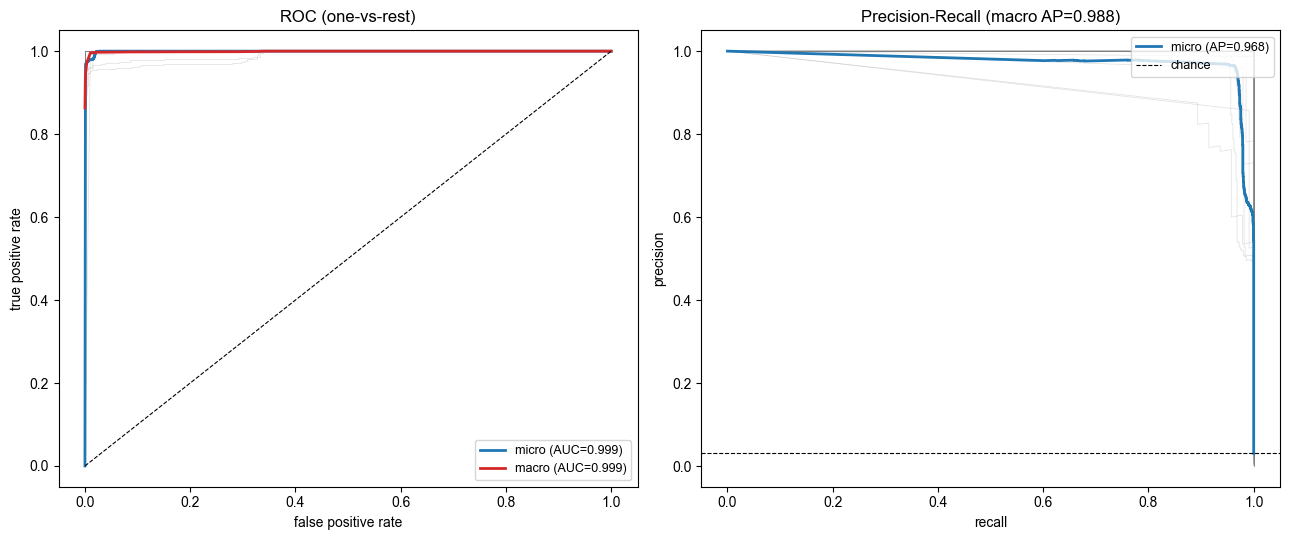

In [10]:
# --- ROC and Precision-Recall curves (one-vs-rest) ----------------------
n_cls = len(present)
fpr, tpr, roc_auc = {}, {}, {}
prec, rec, ap = {}, {}, {}
for i in range(n_cls):
    fpr[i], tpr[i], _ = roc_curve(Yb[:, i], Pp[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    prec[i], rec[i], _ = precision_recall_curve(Yb[:, i], Pp[:, i])
    ap[i] = average_precision_score(Yb[:, i], Pp[:, i])

fpr_mi, tpr_mi, _ = roc_curve(Yb.ravel(), Pp.ravel())          # micro-average
prec_mi, rec_mi, _ = precision_recall_curve(Yb.ravel(), Pp.ravel())
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_cls)]))
mean_tpr = np.mean([np.interp(all_fpr, fpr[i], tpr[i]) for i in range(n_cls)], axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
for i in range(n_cls):
    ax1.plot(fpr[i], tpr[i], lw=0.5, alpha=0.25, color='gray')
ax1.plot(fpr_mi, tpr_mi, lw=2, color='C0', label=f'micro (AUC={auc_micro:.3f})')
ax1.plot(all_fpr, mean_tpr, lw=2, color='C3', label=f'macro (AUC={auc_macro:.3f})')
ax1.plot([0, 1], [0, 1], ls='--', color='k', lw=0.8)
ax1.set_xlabel('false positive rate'); ax1.set_ylabel('true positive rate')
ax1.set_title('ROC (one-vs-rest)'); ax1.legend(loc='lower right', fontsize=9)

for i in range(n_cls):
    ax2.plot(rec[i], prec[i], lw=0.5, alpha=0.25, color='gray')
ax2.plot(rec_mi, prec_mi, lw=2, color='C0', label=f'micro (AP={ap_micro:.3f})')
ax2.axhline(Yb.mean(), ls='--', color='k', lw=0.8, label='chance')
ax2.set_xlabel('recall'); ax2.set_ylabel('precision')
ax2.set_title(f'Precision-Recall (macro AP={ap_macro:.3f})')
ax2.legend(loc='upper right', fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'm3c_roc_pr_curves.pdf'))
plt.show()


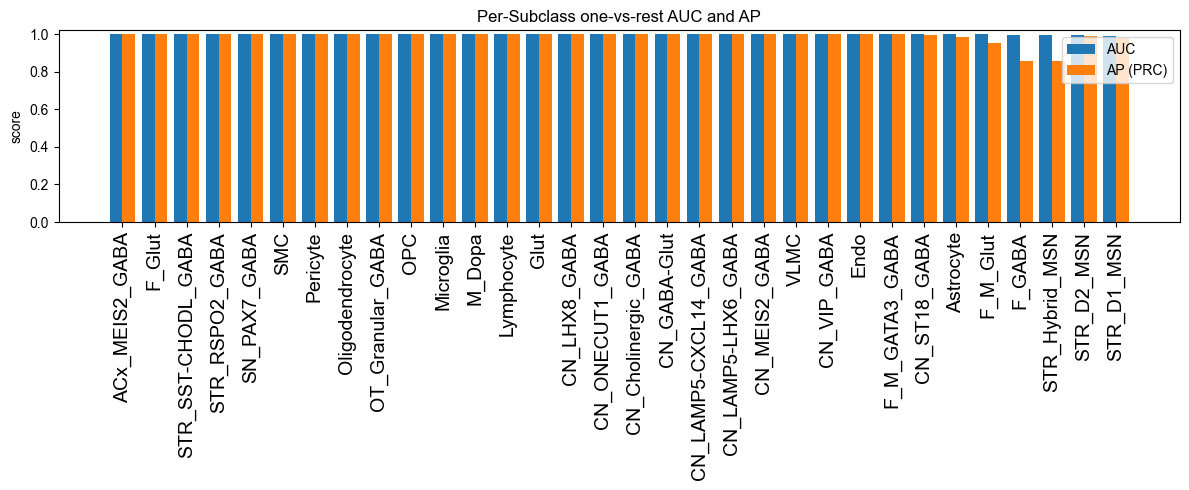

,AUC,AP,support
ACx_MEIS2_GABA,1.0000,1.0000,1
F_Glut,1.0000,1.0000,13
STR_SST-CHODL_GABA,1.0000,1.0000,5
STR_RSPO2_GABA,1.0000,1.0000,2
SN_PAX7_GABA,1.0000,1.0000,2
SMC,1.0000,1.0000,1
Pericyte,1.0000,1.0000,6
Oligodendrocyte,1.0000,1.0000,363
OT_Granular_GABA,1.0000,1.0000,5
OPC,1.0000,1.0000,23


In [11]:
# --- per-LEVEL one-vs-rest AUC / AP bars --------------------------------
support = pd.Series(y_true).value_counts().reindex(present).fillna(0).astype(int)
per = pd.DataFrame({
    'AUC': [roc_auc[i] for i in range(n_cls)],
    'AP':  [ap[i] for i in range(n_cls)],
    'support': support.values,
}, index=present).sort_values('AUC', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(per))
ax.bar(x - 0.2, per['AUC'], width=0.4, label='AUC', color='C0')
ax.bar(x + 0.2, per['AP'], width=0.4, label='AP (PRC)', color='C1')
ax.set_xticks(x); ax.set_xticklabels(per.index, rotation=90, fontsize=14)
ax.set_ylim(0, 1.02); ax.set_ylabel('score')
ax.set_title(f'Per-{LEVEL} one-vs-rest AUC and AP')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'm3c_per_class_auc_ap.pdf'))
plt.show()

per.round(4)


## 9. NEXT — Benchmark (run later)

**Do not run yet.** Measure runtime / peak memory and sweep robustness knobs
(`max_query_cg` / `max_query_ch` downsampling, `top_cg` / `top_ch`, `lambda_ch`, `prior_alpha`)
against accuracy. To be filled in after validation.

---
## 10. Predict & validate on MiSeq cells (BICAN, all samples)

Same trained model, a different query set: **shallow MiSeq** single cells pooled across all
`~/Projects/BICAN/miseq/*/cz/*.cz` samples, intersected with `META_TSV` and randomly subsampled to
`N_QUERY`. We reuse the model under `OUTDIR/model` (symlinked into a separate `OUTDIR/miseq_BICAN` so
fitting is skipped and the deep-cell predictions above are not overwritten), classify the MiSeq `.cz`,
then score them against the **same** `META_TSV` labels and redraw the confusion matrix, ROC/PR curves
and per-`LEVEL` AUC/AP bars.

In [12]:
# --- MiSeq query cells: 2000 random shallow .cz from BICAN --------------
# Pool all MiSeq .cz across samples, keep those annotated in META_TSV, random-pick N_QUERY.
_all_cz_ms = glob.glob(os.path.expanduser('~/Projects/BICAN/miseq/*/cz/*.cz'))
_pool_ms = {os.path.basename(p)[:-3]: p for p in _all_cz_ms
            if os.path.basename(p)[:-3] in _meta_ids}        # stem -> path, in META only
_ids_ms = sorted(_pool_ms)
rng = np.random.default_rng(SEED)
_pick_ms = rng.choice(len(_ids_ms), size=min(N_QUERY, len(_ids_ms)), replace=False)
query_ms = {_ids_ms[i]: _pool_ms[_ids_ms[i]] for i in _pick_ms}   # {cell_id: cz_path}
print(f'{len(_all_cz_ms)} MiSeq .cz found; {len(_pool_ms)} intersect META_TSV; '
      f'sampled {len(query_ms)} query cells')

# separate outdir so MiSeq predictions don't overwrite the deep-cell ones;
# symlink the trained model in so fitting is skipped (model store reused).
MISEQ_OUTDIR = os.path.join(OUTDIR, 'miseq_BICAN')
os.makedirs(MISEQ_OUTDIR, exist_ok=True)
_miseq_model = os.path.join(MISEQ_OUTDIR, 'model')
if not os.path.exists(_miseq_model):
    os.symlink(MODEL_DIR, _miseq_model)

t0 = time.time()
labels_ms, proba_ms = predict_cell_type(
    query=query_ms,
    outdir=MISEQ_OUTDIR,       # reuses OUTDIR/model
    prefix='miseq_',           # -> MISEQ_OUTDIR/miseq_predictions.csv + miseq_predict_proba.csv
    reference=REFERENCE,       # only used if the model must be re-fit
    prior_alpha=0.0,           # uniform prior
    n_jobs=N_JOBS,
    cov_cap=COV_CAP,
    max_query_cg=MAX_QUERY_CG, max_query_ch=MAX_QUERY_CH,
)
print(f'predicted {len(labels_ms)} MiSeq cells in {time.time() - t0:.1f}s')
print('confidence: mean=%.3f  median=%.3f' % (labels_ms['confidence'].mean(),
                                              labels_ms['confidence'].median()))
labels_ms.head()

2026-08-10 03:19:40.981 | INFO     | cytozip.model:fit:851 - found existing model at /home/x-wding2/Projects/BG/pseudobulk/Subclass/model_Subclass/miseq_BICAN/model; skipping fit and loading it


311351 MiSeq .cz found; 28932 intersect META_TSV; sampled 2000 query cells


2026-08-10 07:43:16.642 | INFO     | cytozip.model:predict_cell_type:2650 - wrote predictions to /home/x-wding2/Projects/BG/pseudobulk/Subclass/model_Subclass/miseq_BICAN


predicted 2000 MiSeq cells in 15816.6s
confidence: mean=0.937  median=1.000


,label,confidence
cell_id,,
UCI4723_CX1416_Pu_1_P2-1-A6-C14,STR_Hybrid_MSN,0.999719
UCI2424_CX1718BS0102_MGM1_1_P6-1-A22-G13,Pericyte,1.000000
UCI2424_CX12_NAC_1_P9-1-F19-I2,STR_D2_MSN,0.855092
H1930004_CX47_CaB_1_P8-1-A7-I1,STR_D1_MSN,0.926907
UCI4723_CX1416_Pu_1_P3-1-F8-J14,CN_ST18_GABA,0.966480


In [13]:
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve, auc)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
try:
    mpl.rcParams['font.family'] = 'Arial'
except Exception:
    pass
# --- validate MiSeq predictions against the same META_TSV LEVEL labels ---
# BICAN MiSeq .cz stems match the META_TSV cell ids directly (no id remap needed).
META_TSV = os.path.expanduser('~/Projects/BG/clustering/100kb/cell_metadata_with_annotation.tsv')

_id_col = pd.read_csv(META_TSV, sep='\t', nrows=1).columns[0]
meta = pd.read_csv(META_TSV, sep='\t', usecols=[_id_col, LEVEL],
                   dtype=str).set_index(_id_col)
matched = labels_ms.index.isin(meta.index).sum()
print(f"metadata id column: {_id_col!r}; {matched}/{len(labels_ms)} MiSeq cells matched")

y_true_all = (meta[LEVEL].reindex(labels_ms.index)
              .str.replace(' ', '_', regex=False))
model_classes = list(proba_ms.columns)
mask = y_true_all.notna() & y_true_all.isin(model_classes)
n_out = int((y_true_all.notna() & ~y_true_all.isin(model_classes)).sum())
print(f'{int(mask.sum())}/{len(labels_ms)} cells evaluable '
      f'(labelled & label in the {len(model_classes)} model classes); '
      f'{n_out} labelled but outside model, {int(y_true_all.isna().sum())} unlabelled')

y_true = y_true_all[mask]
y_pred = labels_ms.loc[mask, 'label']
present = [c for c in model_classes if (y_true == c).any()]
P = proba_ms.loc[mask, present]
Yb = label_binarize(y_true, classes=present)
Pp = P.values

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, labels=present, average='macro', zero_division=0)
f1_micro = f1_score(y_true, y_pred, labels=present, average='micro', zero_division=0)
auc_macro = roc_auc_score(Yb, Pp, average='macro')
auc_micro = roc_auc_score(Yb, Pp, average='micro')
ap_macro = average_precision_score(Yb, Pp, average='macro')
ap_micro = average_precision_score(Yb, Pp, average='micro')

print(f'\n=== MiSeq BICAN overall ({LEVEL}) ===')
print(f'evaluated cells  : {len(y_true)}   classes seen: {len(present)}/{len(model_classes)}')
print(f'accuracy         : {acc:.4f}')
print(f'F1  macro / micro: {f1_macro:.4f} / {f1_micro:.4f}')
print(f'AUC macro / micro: {auc_macro:.4f} / {auc_micro:.4f}')
print(f'AP  macro / micro: {ap_macro:.4f} / {ap_micro:.4f}  (PRC)')

FIG_DIR = os.path.join(MISEQ_OUTDIR, 'validation')
os.makedirs(FIG_DIR, exist_ok=True)

metadata id column: 'cell'; 2000/2000 MiSeq cells matched
1984/2000 cells evaluable (labelled & label in the 32 model classes); 16 labelled but outside model, 0 unlabelled

=== MiSeq BICAN overall (Subclass) ===
evaluated cells  : 1984   classes seen: 29/32
accuracy         : 0.7722
F1  macro / micro: 0.7513 / 0.7732
AUC macro / micro: 0.9854 / 0.9869
AP  macro / micro: 0.8334 / 0.8076  (PRC)


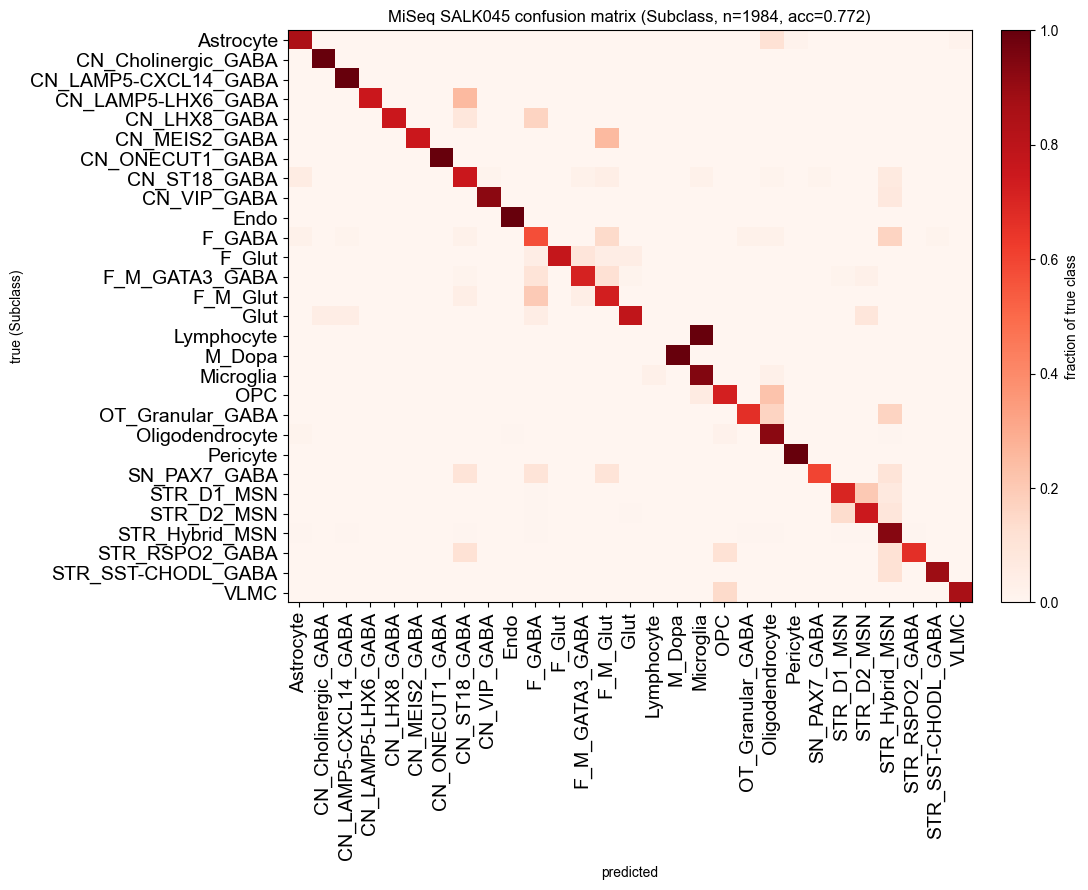

In [14]:
# --- MiSeq row-normalised confusion matrix ------------------------------
cm = confusion_matrix(y_true, y_pred, labels=present)
cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cmn, cmap='Reds', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(present))); ax.set_xticklabels(present, rotation=90, fontsize=14)
ax.set_yticks(range(len(present))); ax.set_yticklabels(present, fontsize=14)
ax.set_xlabel('predicted'); ax.set_ylabel(f'true ({LEVEL})')
ax.set_title(f'MiSeq SALK045 confusion matrix ({LEVEL}, n={len(y_true)}, acc={acc:.3f})')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='fraction of true class')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'miseq_confusion_matrix.pdf'))
plt.show()


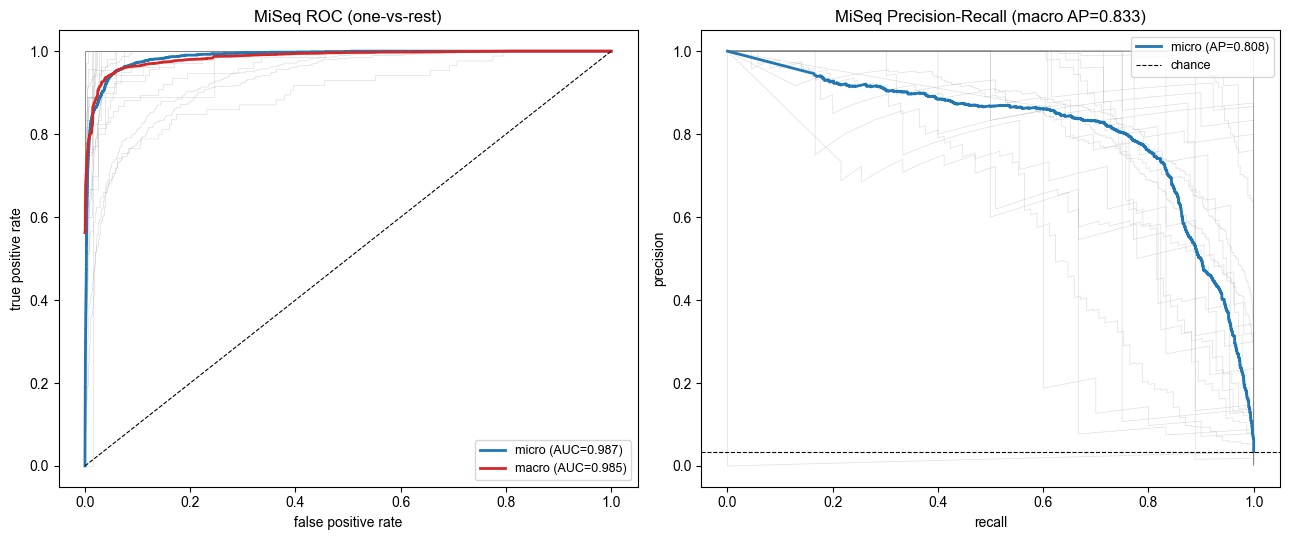

In [15]:
# --- MiSeq ROC and Precision-Recall curves (one-vs-rest) ----------------
n_cls = len(present)
fpr, tpr, roc_auc = {}, {}, {}
prec, rec, ap = {}, {}, {}
for i in range(n_cls):
    fpr[i], tpr[i], _ = roc_curve(Yb[:, i], Pp[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    prec[i], rec[i], _ = precision_recall_curve(Yb[:, i], Pp[:, i])
    ap[i] = average_precision_score(Yb[:, i], Pp[:, i])

fpr_mi, tpr_mi, _ = roc_curve(Yb.ravel(), Pp.ravel())
prec_mi, rec_mi, _ = precision_recall_curve(Yb.ravel(), Pp.ravel())
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_cls)]))
mean_tpr = np.mean([np.interp(all_fpr, fpr[i], tpr[i]) for i in range(n_cls)], axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
for i in range(n_cls):
    ax1.plot(fpr[i], tpr[i], lw=0.5, alpha=0.25, color='gray')
ax1.plot(fpr_mi, tpr_mi, lw=2, color='C0', label=f'micro (AUC={auc_micro:.3f})')
ax1.plot(all_fpr, mean_tpr, lw=2, color='C3', label=f'macro (AUC={auc_macro:.3f})')
ax1.plot([0, 1], [0, 1], ls='--', color='k', lw=0.8)
ax1.set_xlabel('false positive rate'); ax1.set_ylabel('true positive rate')
ax1.set_title('MiSeq ROC (one-vs-rest)'); ax1.legend(loc='lower right', fontsize=9)

for i in range(n_cls):
    ax2.plot(rec[i], prec[i], lw=0.5, alpha=0.25, color='gray')
ax2.plot(rec_mi, prec_mi, lw=2, color='C0', label=f'micro (AP={ap_micro:.3f})')
ax2.axhline(Yb.mean(), ls='--', color='k', lw=0.8, label='chance')
ax2.set_xlabel('recall'); ax2.set_ylabel('precision')
ax2.set_title(f'MiSeq Precision-Recall (macro AP={ap_macro:.3f})')
ax2.legend(loc='upper right', fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'miseq_roc_pr_curves.pdf'))
plt.show()


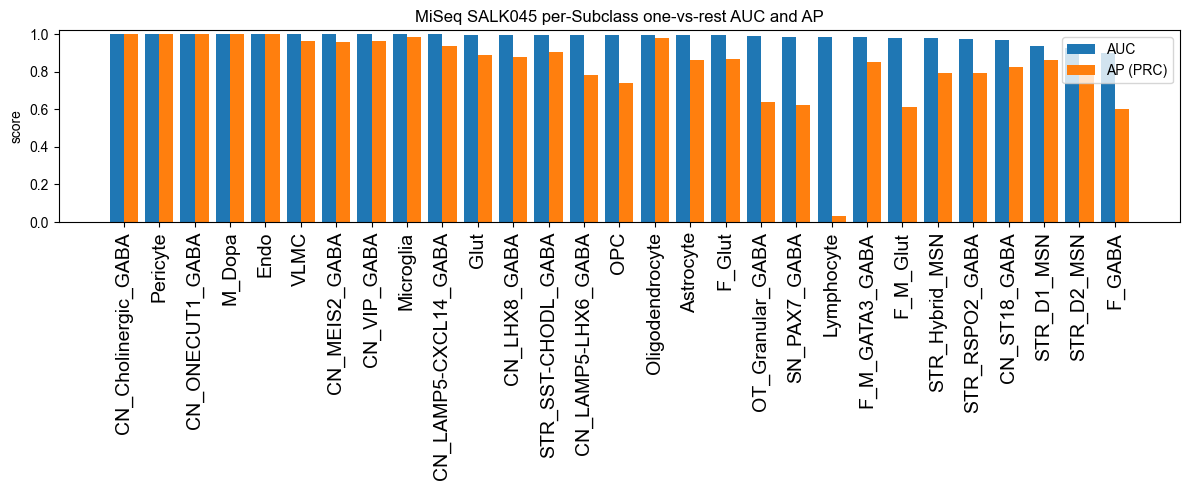

,AUC,AP,support
CN_Cholinergic_GABA,1.0000,1.0000,2
Pericyte,1.0000,1.0000,7
CN_ONECUT1_GABA,1.0000,1.0000,5
M_Dopa,1.0000,1.0000,4
Endo,1.0000,1.0000,3
VLMC,0.9999,0.9617,7
CN_MEIS2_GABA,0.9998,0.9594,8
CN_VIP_GABA,0.9998,0.9627,13
Microglia,0.9997,0.9875,35
CN_LAMP5-CXCL14_GABA,0.9997,0.9354,10


In [16]:
# --- MiSeq per-LEVEL one-vs-rest AUC / AP bars --------------------------
support = pd.Series(y_true).value_counts().reindex(present).fillna(0).astype(int)
per = pd.DataFrame({
    'AUC': [roc_auc[i] for i in range(n_cls)],
    'AP':  [ap[i] for i in range(n_cls)],
    'support': support.values,
}, index=present).sort_values('AUC', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(per))
ax.bar(x - 0.2, per['AUC'], width=0.4, label='AUC', color='C0')
ax.bar(x + 0.2, per['AP'], width=0.4, label='AP (PRC)', color='C1')
ax.set_xticks(x); ax.set_xticklabels(per.index, rotation=90, fontsize=14)
ax.set_ylim(0, 1.02); ax.set_ylabel('score')
ax.set_title(f'MiSeq SALK045 per-{LEVEL} one-vs-rest AUC and AP')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'miseq_per_class_auc_ap.pdf'))
plt.show()

per.round(4)
